In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# プロットのスタイル設定
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

Fig 3 Data Loaded.


/home/mori-lab/shimizu/aco-on-spinglass/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/tmp/ipykernel_690844/2030226085.py:32: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5) # m=0


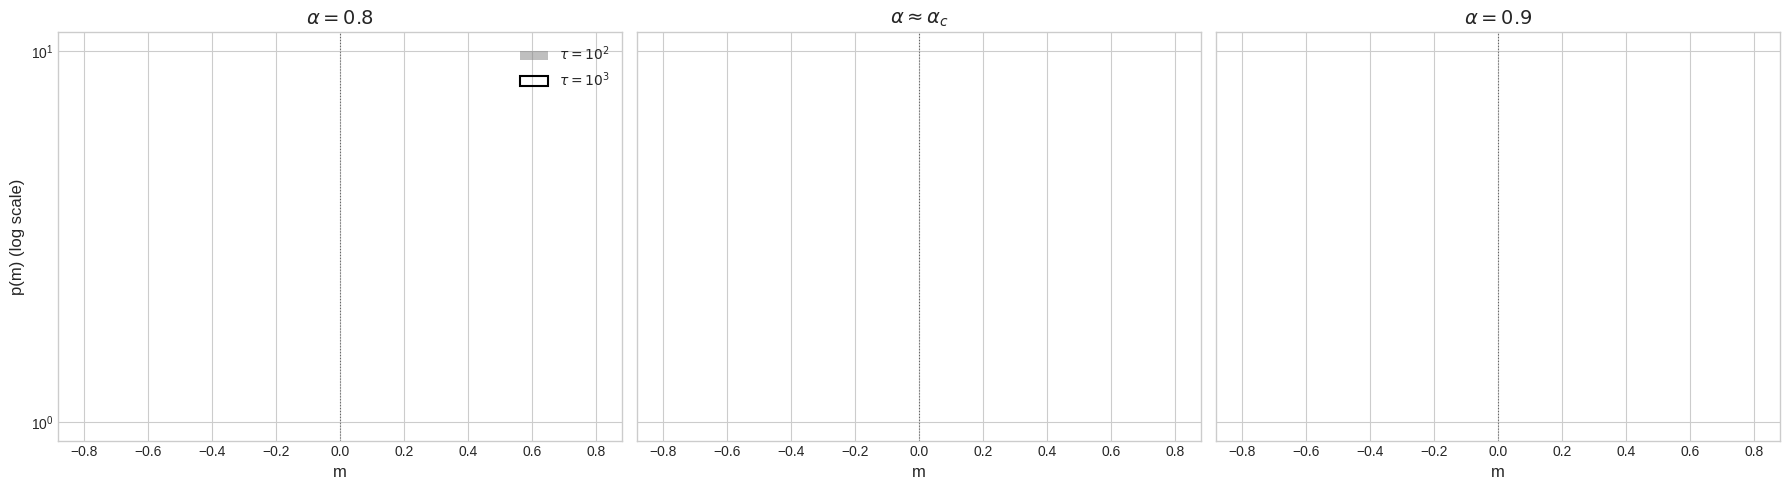

In [40]:
# データ読み込み
try:
    df3 = pd.read_csv("aco_fig3_data.csv")
    print("Fig 3 Data Loaded.")
except FileNotFoundError:
    print("Error: 'aco_fig3_data.csv' not found.")

# パラメータ
target_alphas = [0.8, 0.83515, 0.9]
titles = [r"$\alpha=0.8$", r"$\alpha \approx \alpha_c$", r"$\alpha=0.9$"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
bins = np.linspace(-0.8, 0.8, 50)

for i, alpha_target in enumerate(target_alphas):
    ax = axes[i]
    # alpha値でフィルタリング (浮動小数点誤差を許容)
    subset = df3[np.isclose(df3['alpha'], alpha_target, atol=1e-4)]
    
    # tau=100 (Filled Histogram)
    data_100 = subset[subset['tau'] == 100]['m_value']
    ax.hist(data_100, bins=bins, alpha=0.5, label=r'$\tau=10^2$', 
            density=True, log=True, color='gray', edgecolor='none')
    
    # tau=1000 (Step Histogram)
    data_1000 = subset[subset['tau'] == 1000]['m_value']
    ax.hist(data_1000, bins=bins, alpha=1.0, label=r'$\tau=10^3$', 
            density=True, log=True, color='black', histtype='step', linewidth=1.5)
    
    ax.set_title(titles[i], fontsize=14)
    ax.set_xlabel("m", fontsize=12)
    ax.axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5) # m=0

axes[0].set_ylabel("p(m) (log scale)", fontsize=12)
axes[0].legend()
plt.tight_layout()
plt.show()

Fig 4 Data Loaded.


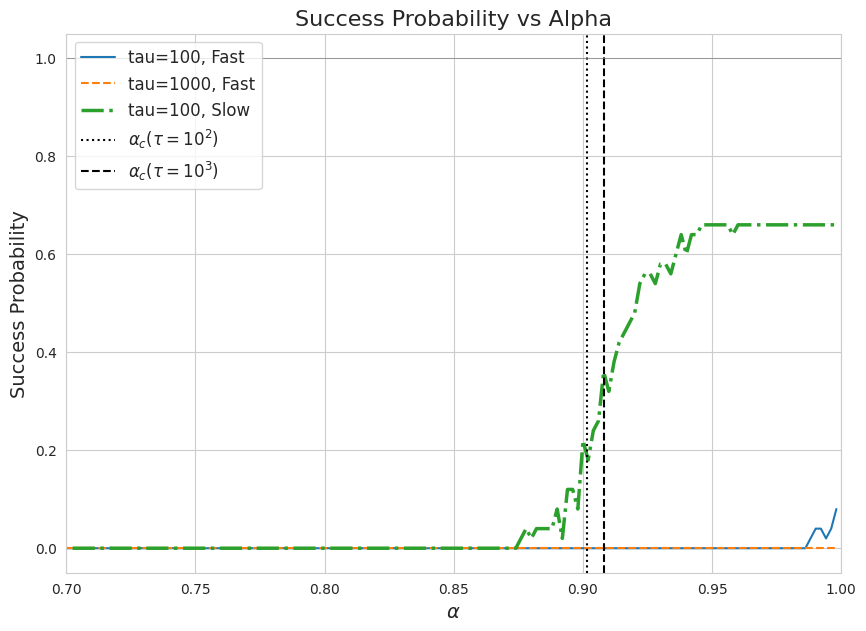

In [10]:
# データ読み込み
try:
    df4 = pd.read_csv("aco_fig4_data.csv")
    print("Fig 4 Data Loaded.")
except FileNotFoundError:
    print("Error: 'aco_fig4_data.csv' not found.")

plt.figure(figsize=(10, 7))

# 理論的な alpha_c の計算 (J=0.1, tau=100)
J = 0.1

def alpha_c(tau):
    term1 = tau * (J + 1)
    return (np.sqrt(term1**2 + 4*tau) - term1) / 2

# プロット
labels = df4['label'].unique()
linestyles = ['-', '--', '-.', ':']

for i, label in enumerate(labels):
    subset = df4[df4['label'] == label].sort_values(by='alpha')
    
    # 論文のスタイルに似せる
    ls = linestyles[i % len(linestyles)]
    lw = 2.5 if "Slow" in label else 1.5
    
    plt.plot(subset['alpha'], subset['success_prob'], 
             label=label, linestyle=ls, linewidth=lw)

# 補助線
plt.axvline(x=alpha_c(100), color='black', linestyle=':', label=r'$\alpha_c (\tau=10^2)$')
plt.axvline(x=alpha_c(1000), color='black', linestyle='--', label=r'$\alpha_c (\tau=10^3)$')
plt.axhline(y=1.0, color='gray', linestyle='-', linewidth=0.5)

plt.xlabel(r"$\alpha$", fontsize=14)
plt.ylabel("Success Probability", fontsize=14)
plt.title("Success Probability vs Alpha", fontsize=16)
plt.xlim(0.7, 1.0) # 変化が起きる領域を拡大
plt.ylim(-0.05, 1.05)
plt.legend(fontsize=12, loc='upper left')
plt.show()

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# グラフのスタイル設定（お好みで変更可能です）
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

# データの読み込み
try:
    df3 = pd.read_csv('figure3_data_custom.csv')
    df4 = pd.read_csv('figure4_data.csv')
    print("データの読み込みに成功しました。")
    print(f"Figure 3 data shape: {df3.shape}")
    print(f"Figure 4 data shape: {df4.shape}")
except FileNotFoundError as e:
    print(f"エラー: CSVファイルが見つかりません。Juliaコードを実行してCSVを生成してください。\n{e}")

データの読み込みに成功しました。
Figure 3 data shape: (1200000, 3)
Figure 4 data shape: (244, 4)


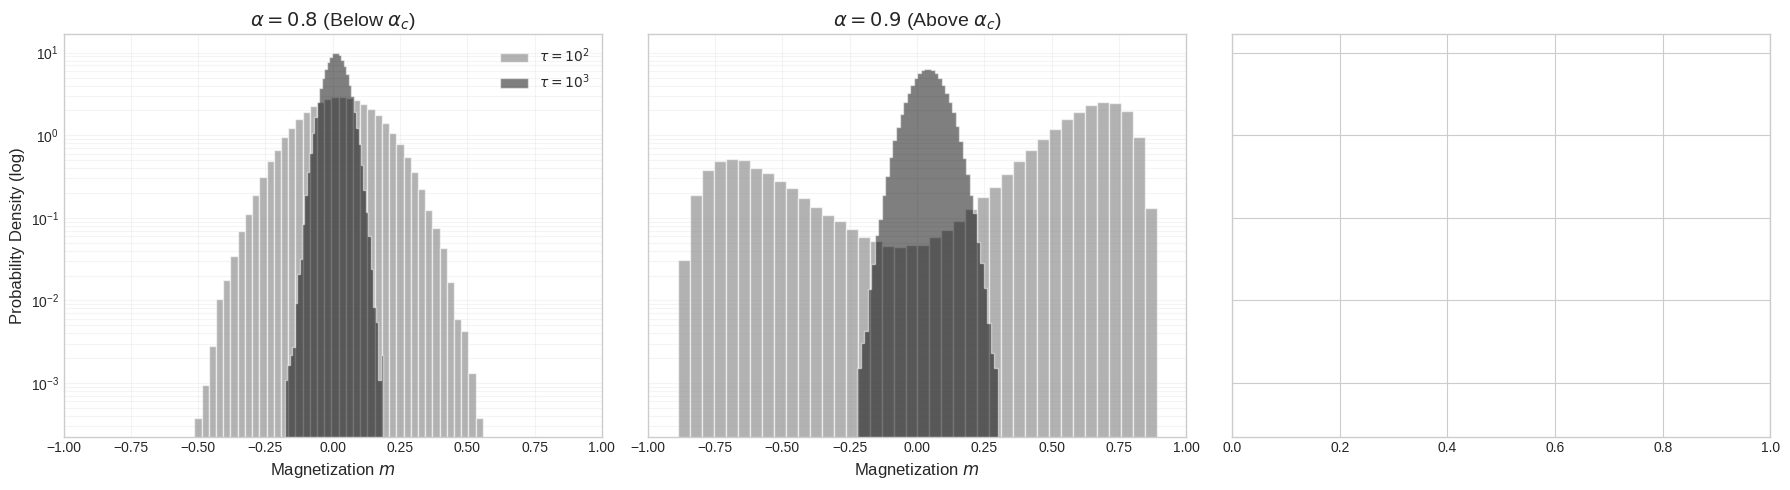

In [48]:
# Figure 3の再現
def plot_figure3(df):
    target_alphas = [0.8, 0.9]
    titles = {
        0.8: r'$\alpha = 0.8$ (Below $\alpha_c$)',
        0.835: r'$\alpha \approx \alpha_c$ (Critical)',
        0.9: r'$\alpha = 0.9$ (Above $\alpha_c$)'
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    
    # 各αについてプロット
    for i, alpha_val in enumerate(target_alphas):
        ax = axes[i]
        
        # データの抽出 (浮動小数点の誤差を考慮してnp.iscloseを使用)
        data_tau100 = df[
            (df['tau'] == 100) & 
            (np.isclose(df['alpha_target'], alpha_val))
        ]['magnetization']
        
        data_tau1000 = df[
            (df['tau'] == 1000) & 
            (np.isclose(df['alpha_target'], alpha_val))
        ]['magnetization']
        
        # ヒストグラムの描画 (論文に合わせてlog=True)
        # tau=100 (薄いグレー)
        ax.hist(data_tau100, bins=40, density=True, log=True,
                color='gray', alpha=0.6, label=r'$\tau=10^2$')
        
        # tau=1000 (濃い黒/グレー)
        ax.hist(data_tau1000, bins=40, density=True, log=True,
                color='black', alpha=0.5, histtype='stepfilled', label=r'$\tau=10^3$')
        
        # 装飾
        ax.set_title(titles.get(alpha_val, f'alpha={alpha_val}'), fontsize=14)
        ax.set_xlabel('Magnetization $m$', fontsize=12)
        ax.set_xlim(-1.0, 1.0)
        ax.grid(True, which="both", ls="-", alpha=0.2)
        
        # α_cの場合の基準線
        if alpha_val == 0.835:
            ax.axvline(0, color='black', linestyle='--', linewidth=1)

        if i == 0:
            ax.set_ylabel('Probability Density (log)', fontsize=12)
            ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

if 'df3' in locals():
    plot_figure3(df3)

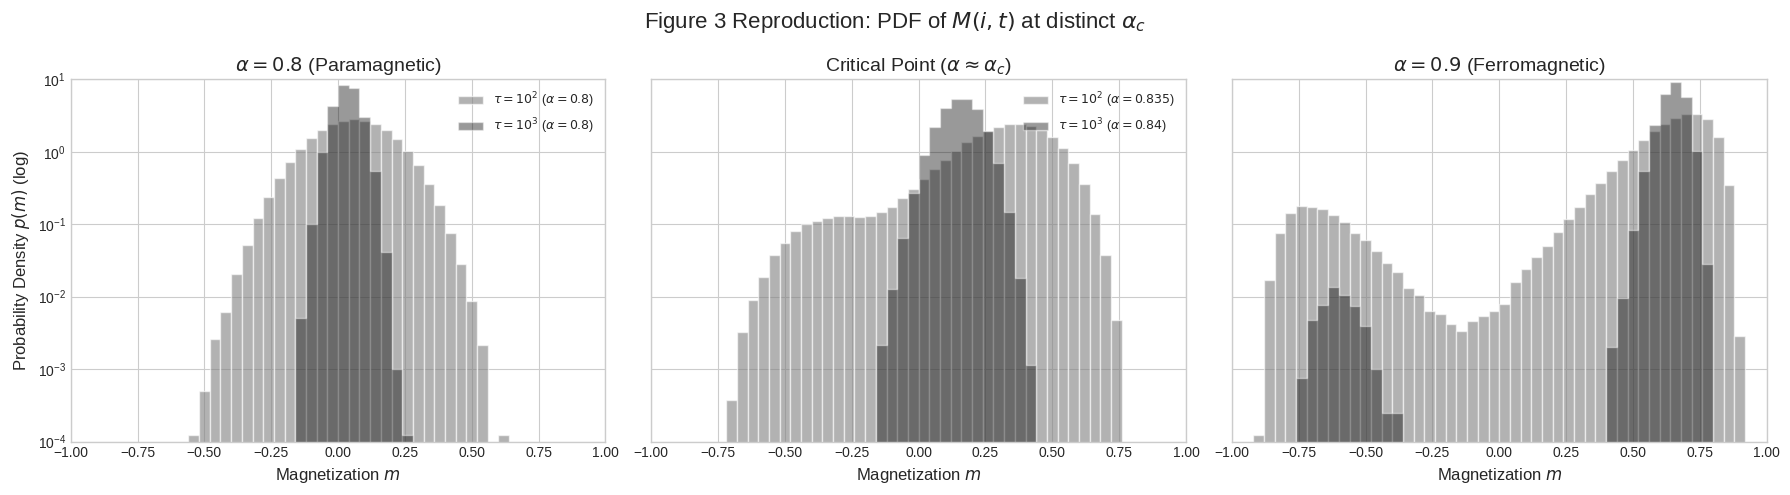

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Julia側で指定した値をここにも設定してください
ALPHA_C_TAU100  = 0.835
ALPHA_C_TAU1000 = 0.84  # 必要に応じて変更

def plot_figure3_overlay(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print("CSVファイルが見つかりません。Juliaコードを実行してください。")
        return

    # 3つのプロット条件を定義
    # (タイトル, tau=100の抽出alpha, tau=1000の抽出alpha)
    conditions = [
        (r'$\alpha = 0.8$ (Paramagnetic)', 0.8, 0.8),
        (r'Critical Point ($\alpha \approx \alpha_c$)', ALPHA_C_TAU100, ALPHA_C_TAU1000),
        (r'$\alpha = 0.9$ (Ferromagnetic)', 0.9, 0.9)
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    plt.subplots_adjust(wspace=0.1)

    # 共通設定
    bins = 50
    range_lim = (-1.0, 1.0)

    for i, (title, target_100, target_1000) in enumerate(conditions):
        ax = axes[i]
        
        # --- tau=100 のデータ抽出 ---
        # alpha が target_100 に近いデータを抽出
        data_100 = df[
            (df['tau'] == 100) & 
            (np.isclose(df['alpha_target'], target_100, atol=1e-4))
        ]['magnetization']
        
        # --- tau=1000 のデータ抽出 ---
        # alpha が target_1000 に近いデータを抽出
        data_1000 = df[
            (df['tau'] == 1000) & 
            (np.isclose(df['alpha_target'], target_1000, atol=1e-4))
        ]['magnetization']

        # ヒストグラムの描画
        # tau=100: グレー
        ax.hist(data_100, bins=bins, range=range_lim, density=True, log=True,
                color='gray', alpha=0.6, label=r'$\tau=10^2$ ' + f'($\\alpha={target_100}$)')
        
        # tau=1000: 黒（透過）
        ax.hist(data_1000, bins=bins, range=range_lim, density=True, log=True,
                color='black', alpha=0.4, histtype='stepfilled', 
                label=r'$\tau=10^3$ ' + f'($\\alpha={target_1000}$)')

        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Magnetization $m$', fontsize=12)
        ax.set_xlim(-1.0, 1.0)
        ax.set_ylim(1e-4, 10) # ログスケールの範囲調整
        
        if i == 0:
            ax.set_ylabel('Probability Density $p(m)$ (log)', fontsize=12)
            ax.legend(loc='upper right', fontsize=9)
        elif i == 1:
             ax.legend(loc='upper right', fontsize=9) # 中央にも凡例を表示（異なるalphaを確認するため）

    plt.tight_layout()
    plt.show()

# 実行
plot_figure3_overlay('figure3_data_custom.csv')

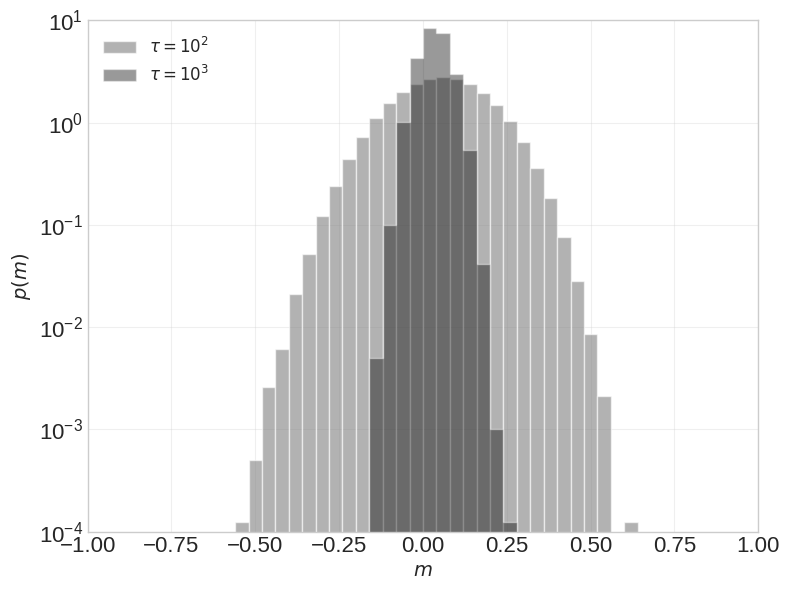

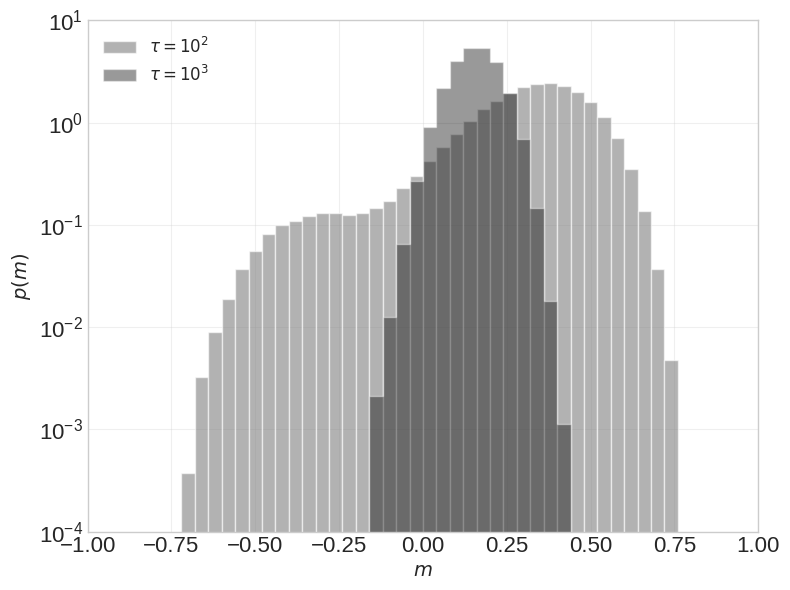

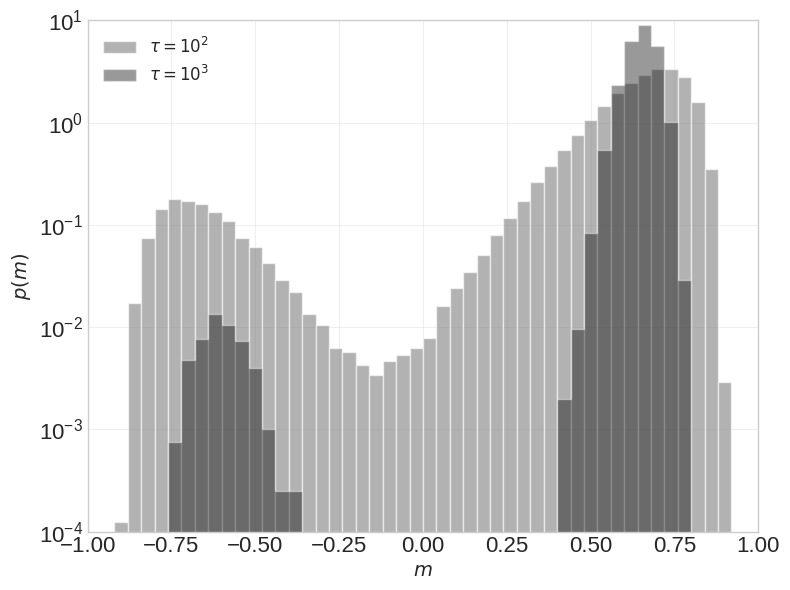

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Julia側で指定した値をここにも設定してください
ALPHA_C_TAU100  = 0.835
ALPHA_C_TAU1000 = 0.84  # 必要に応じて変更

def plot_figure3_separate(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print("CSVファイルが見つかりません。Juliaコードを実行してください。")
        return

    # 3つのプロット条件を定義
    # (タイトル, tau=100の抽出alpha, tau=1000の抽出alpha)
    conditions = [
        (r'$\alpha = 0.8$ (Paramagnetic)', 0.8, 0.8),
        (r'Critical Point ($\alpha \approx \alpha_c$)', ALPHA_C_TAU100, ALPHA_C_TAU1000),
        (r'$\alpha = 0.9$ (Ferromagnetic)', 0.9, 0.9)
    ]

    # 共通設定
    bins = 50
    range_lim = (-1.0, 1.0)

    # ループ内で個別に図を作成して表示
    for title, target_100, target_1000 in conditions:
        # 図の生成（サイズは適宜調整してください）
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # --- tau=100 のデータ抽出 ---
        data_100 = df[
            (df['tau'] == 100) & 
            (np.isclose(df['alpha_target'], target_100, atol=1e-4))
        ]['magnetization']
        
        # --- tau=1000 のデータ抽出 ---
        data_1000 = df[
            (df['tau'] == 1000) & 
            (np.isclose(df['alpha_target'], target_1000, atol=1e-4))
        ]['magnetization']

        # ヒストグラムの描画
        # tau=100: グレー
        ax.hist(data_100, bins=bins, range=range_lim, density=True, log=True,
                color='gray', alpha=0.6, label=r'$\tau=10^2$ ')
        
        # tau=1000: 黒（透過）
        ax.hist(data_1000, bins=bins, range=range_lim, density=True, log=True,
                color='black', alpha=0.4, histtype='stepfilled', 
                label=r'$\tau=10^3$ ')

        # 装飾（すべての図にラベルと凡例を付ける）
        #ax.set_title(title, fontsize=16)
        ax.set_xlabel('$m$', fontsize=14)
        ax.set_ylabel('$p(m)$', fontsize=14)
        ax.set_xlim(-1.0, 1.0)
        ax.set_ylim(1e-4, 10) # ログスケールの範囲調整
        ax.tick_params(labelsize=16)
        
        ax.legend(loc='upper left', fontsize=12)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show() # ここで都度表示する

# 実行
plot_figure3_separate('figure3_data_custom.csv')

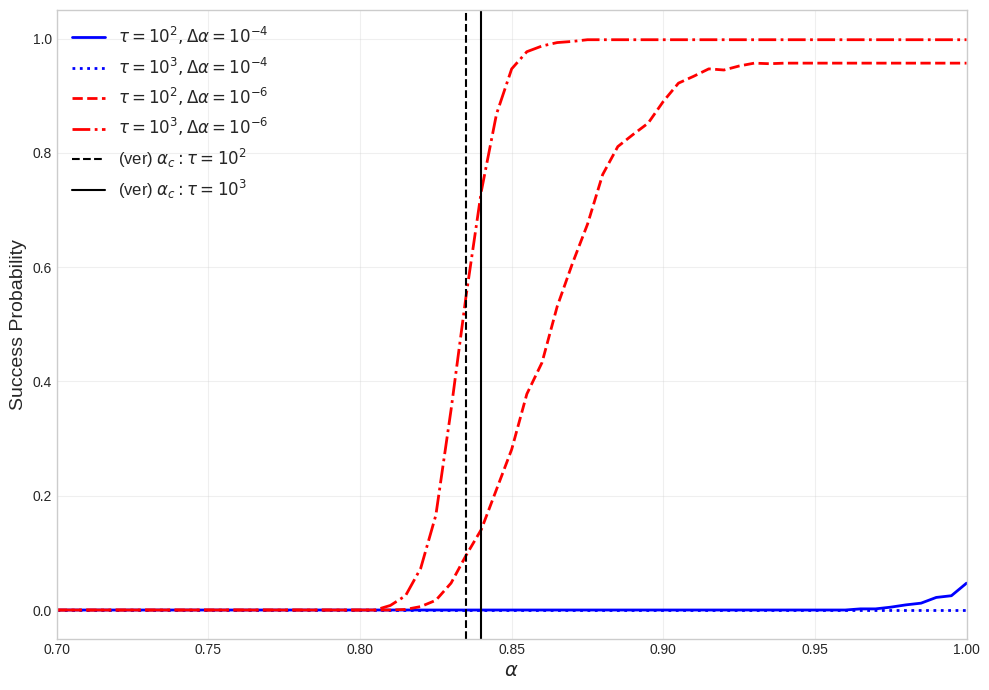

In [39]:
# Figure 4の再現
def plot_figure4(df):
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # プロットする条件とスタイルの定義
    # (Schedule, Tau, Label, Color, LineStyle)
    styles = [
        ("Fast", 100,  r'$\tau=10^2, \Delta \alpha=10^{-4}$', 'blue', '-'),
        ("Fast", 1000, r'$\tau=10^3, \Delta \alpha=10^{-4}$', 'blue', ':'),
        ("Slow", 100,  r'$\tau=10^2, \Delta \alpha=10^{-6}$', 'red', '--'),
        ("Slow", 1000, r'$\tau=10^3, \Delta \alpha=10^{-6}$', 'red', '-.')
    ]
    
    for sched, tau_val, label, color, ls in styles:
        # 条件に合うデータを抽出
        subset = df[
            (df['schedule'] == sched) & 
            (df['tau'] == tau_val)
        ].sort_values(by='alpha')
        
        if not subset.empty:
            ax.plot(subset['alpha'], subset['success_prob'], 
                    label=label, color=color, linestyle=ls, linewidth=2)
    
    # 理論上の臨界点 α_c (J=0.1, h=0.001 の場合 約0.835)
    alpha_c = 0.835
    ax.axvline(0.835, color='black', linestyle='--', linewidth=1.5, label=r'(ver) $\alpha_c:\tau=10^2$')
    ax.axvline(0.84, color='black', linestyle='-', linewidth=1.5, label=r'(ver) $\alpha_c:\tau=10^3$')    

    # 装飾
    ax.set_xlabel(r'$\alpha$', fontsize=14)
    ax.set_ylabel('Success Probability', fontsize=14)
    ax.set_xlim(0.7, 1.0)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if 'df4' in locals():
    plot_figure4(df4)